#  nb-06 — Cluster Profiling & Behavioral Analysis
> **Project:** Customer Profiling and Behavioral Prediction Using ML for Personalized Recommendation Systems  
> **Input:** `features_with_clusters.csv` + `platform_profiles.csv` (from nb-05)  
> **Goal:** Build deep behavioral profiles per segment for the recommendation engine  
> **Segments:** Satisfied Loyal Shoppers | Frustrated Complainers | Neutral Browsers | Impulsive Buyers | Engaged Brand Advocates  
> **Tracking:** MLflow

In [1]:
import subprocess
subprocess.run(['pip', 'install', 'mlflow', '-q'])

import os, json, warnings, logging
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')
log = logging.getLogger(__name__)

import pandas as pd
import numpy as np
import joblib
import mlflow

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.stats import f_oneway, kruskal, chi2_contingency
from tqdm.auto import tqdm

SEED = 42
np.random.seed(SEED)

print('=' * 55)
print('  nb-06 — Cluster Profiling & Behavioral Analysis')
print('=' * 55)
print(f'  Started : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print('=' * 55)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 17.0 MB/s eta 0:00:00


2026-04-25 16:48:39,056 | INFO | NumExpr defaulting to 4 threads.


  nb-06 — Cluster Profiling & Behavioral Analysis
  Started : 2026-04-25 16:48:47


# Config & Paths


In [2]:
ON_KAGGLE = os.path.exists('/kaggle/input')

SEGMENT_NAMES = {
    0: 'Satisfied Loyal Shoppers',
    1: 'Frustrated Complainers',
    2: 'Neutral Browsers',
    3: 'Impulsive Buyers',
    4: 'Engaged Brand Advocates',
}

SEGMENT_COLORS = {
    0: '#2ecc71',
    1: '#e74c3c',
    2: '#3498db',
    3: '#f39c12',
    4: '#9b59b6',
}

WORK_DIR = Path('/kaggle/working')
FIG_DIR  = WORK_DIR / 'outputs' / 'figures'
OUT_DIR  = WORK_DIR / 'outputs' / 'profiles'
LOG_DIR  = WORK_DIR / 'mlflow_runs'

for d in [FIG_DIR, OUT_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

CFG = {
    'experiment_name': '04_Cluster_Profiling_Behavioral_Analysis',
    'run_name'       : f'profiling-v1-{datetime.now().strftime("%Y%m%d_%H%M")}',
    'random_state'   : SEED,
    'k'              : 5,
}

print('✅ Config OK')
print(f'   FIG_DIR → {FIG_DIR}')
print(f'   OUT_DIR → {OUT_DIR}')

✅ Config OK
   FIG_DIR → /kaggle/working/outputs/figures
   OUT_DIR → /kaggle/working/outputs/profiles


In [3]:
log.info('Loading clustered data...')

NB05_OUT     = Path('/kaggle/input/notebooks/bennjimatakwa/nb-05-clustering')
DATA_DIR     = NB05_OUT / 'data' / 'processed'
MODEL_DIR    = NB05_OUT / 'clustering'

df               = pd.read_csv(DATA_DIR / 'features_with_clusters.csv')
platform_profile = pd.read_csv(DATA_DIR / 'platform_profiles.csv', index_col=0)
comparison       = pd.read_csv(DATA_DIR / 'clustering_comparison.csv')
scaler           = joblib.load(MODEL_DIR / 'clustering_scaler.pkl')
km_labels        = np.load(MODEL_DIR / 'cluster_labels.npy')

# ── Map segment names & colors
df['segment_name']  = df['final_cluster'].map(SEGMENT_NAMES)
df['segment_color'] = df['final_cluster'].map(SEGMENT_COLORS)

print(f'✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n── Segment distribution ──')
for k, name in SEGMENT_NAMES.items():
    n   = (df['final_cluster'] == k).sum()
    pct = n / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f'   {k} | {name:<30} | {n:>6,} ({pct:4.1f}%)  {bar}')

print(f'\n── Column groups ──')
print(f'   Total columns    : {df.shape[1]}')
print(f'   Sentiment col    : {"sentiment" in df.columns}')
print(f'   Platform col     : {"appName" in df.columns}')
print(f'   Cluster col      : {"final_cluster" in df.columns}')
print(f'   Segment name col : {"segment_name" in df.columns}')

2026-04-25 16:48:47,476 | INFO | Loading clustered data...


✅ Loaded: 99,999 rows × 49 columns

── Segment distribution ──
   0 | Satisfied Loyal Shoppers       | 20,952 (21.0%)  ██████████
   1 | Frustrated Complainers         | 21,851 (21.9%)  ██████████
   2 | Neutral Browsers               | 18,285 (18.3%)  █████████
   3 | Impulsive Buyers               | 20,682 (20.7%)  ██████████
   4 | Engaged Brand Advocates        | 18,229 (18.2%)  █████████

── Column groups ──
   Total columns    : 49
   Sentiment col    : True
   Platform col     : True
   Cluster col      : True
   Segment name col : True


 # Behavioral Feature Heatmap per Segment

2026-04-25 16:48:48,544 | INFO | Building behavioral profiles per segment...


✅ Feature groups:
   Behavior  : 21
   BiLSTM    : 4
   Platform  : 13


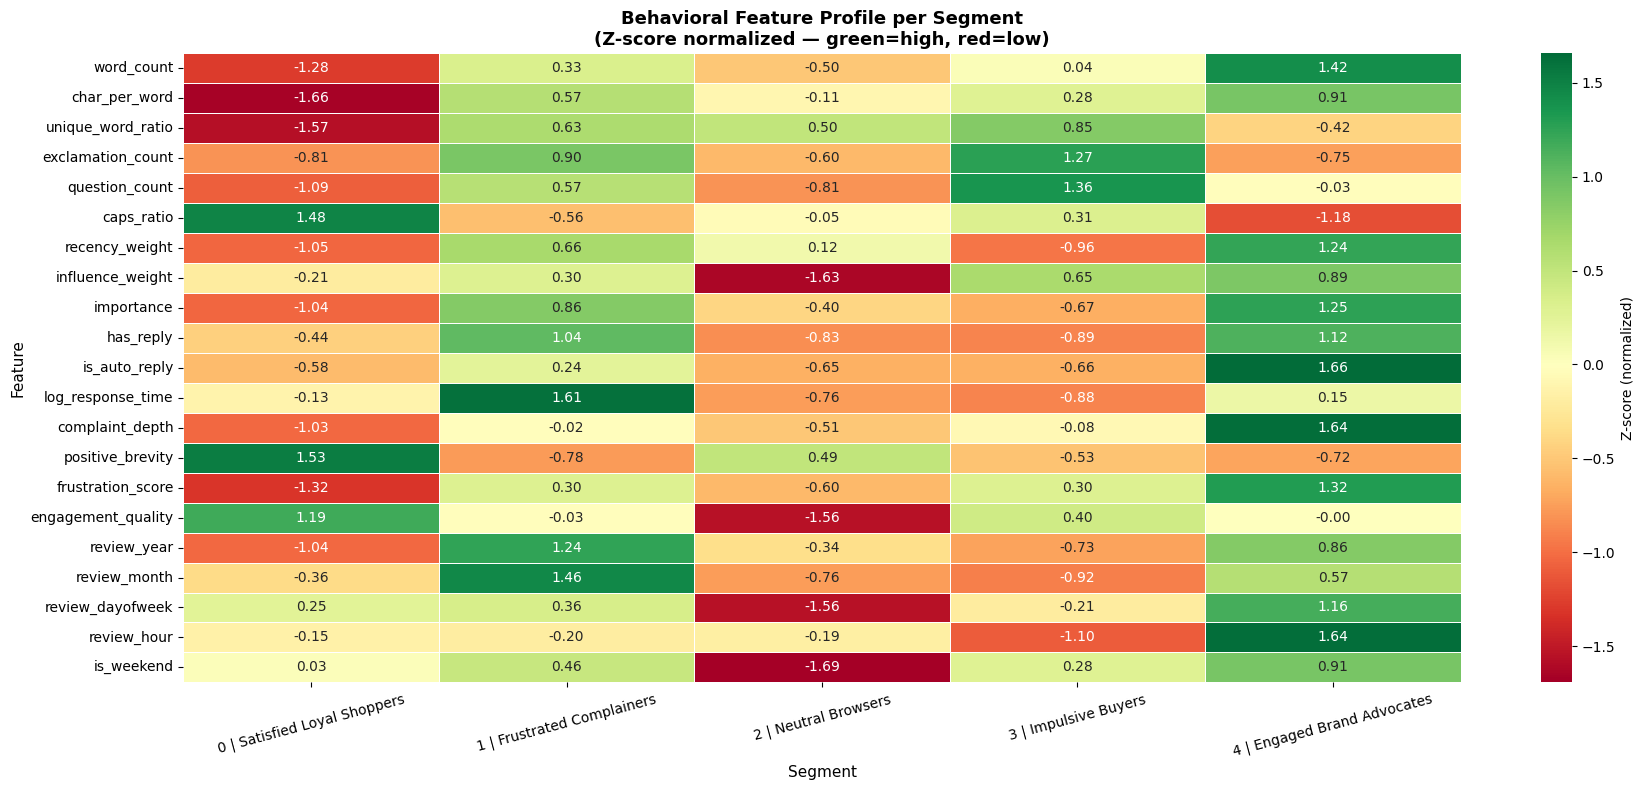


── Top distinguishing feature per segment ──
   Cluster 0 | Satisfied Loyal Shoppers       → char_per_word (▼ LOW)
   Cluster 1 | Frustrated Complainers         → log_response_time (▲ HIGH)
   Cluster 2 | Neutral Browsers               → is_weekend (▼ LOW)
   Cluster 3 | Impulsive Buyers               → question_count (▲ HIGH)
   Cluster 4 | Engaged Brand Advocates        → is_auto_reply (▲ HIGH)


In [4]:
log.info('Building behavioral profiles per segment...')

BEHAVIOR_FEATURES = [
    'word_count', 'char_per_word', 'unique_word_ratio',
    'exclamation_count', 'question_count', 'caps_ratio',
    'recency_weight', 'influence_weight', 'importance',
    'has_reply', 'is_auto_reply', 'log_response_time',
    'complaint_depth', 'positive_brevity',
    'frustration_score', 'engagement_quality',
    'review_year', 'review_month', 'review_dayofweek',
    'review_hour', 'is_weekend'
]
BEHAVIOR_FEATURES = [f for f in BEHAVIOR_FEATURES if f in df.columns]

BILSTM_FEATURES = [f for f in [
    'bilstm_prob_neg', 'bilstm_prob_neu',
    'bilstm_prob_pos', 'bilstm_confidence'
] if f in df.columns]

PLATFORM_FEATURES = [c for c in df.columns if c.startswith('plt_')]

print(f'✅ Feature groups:')
print(f'   Behavior  : {len(BEHAVIOR_FEATURES)}')
print(f'   BiLSTM    : {len(BILSTM_FEATURES)}')
print(f'   Platform  : {len(PLATFORM_FEATURES)}')

# ── Cluster mean profiles
cluster_means = df.groupby('final_cluster')[BEHAVIOR_FEATURES].mean()

# ── Z-score normalize for heatmap
cluster_norm = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-8)
cluster_norm.index = [f'{i} | {SEGMENT_NAMES[i]}' for i in cluster_norm.index]

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(
    cluster_norm.T,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Z-score (normalized)'},
    ax=ax
)
ax.set_title('Behavioral Feature Profile per Segment\n(Z-score normalized — green=high, red=low)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Segment', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_behavioral_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print top distinguishing feature per segment
print('\n── Top distinguishing feature per segment ──')
for i in range(CFG['k']):
    col = f'{i} | {SEGMENT_NAMES[i]}'
    top = cluster_norm.T[col].abs().idxmax()
    val = cluster_norm.T[col][top]
    direction = '▲ HIGH' if val > 0 else '▼ LOW'
    print(f'   Cluster {i} | {SEGMENT_NAMES[i]:<30} → {top} ({direction})')

#  Sentiment Deep-Dive per Segment

2026-04-25 16:48:50,014 | INFO | Analyzing sentiment distribution per segment...


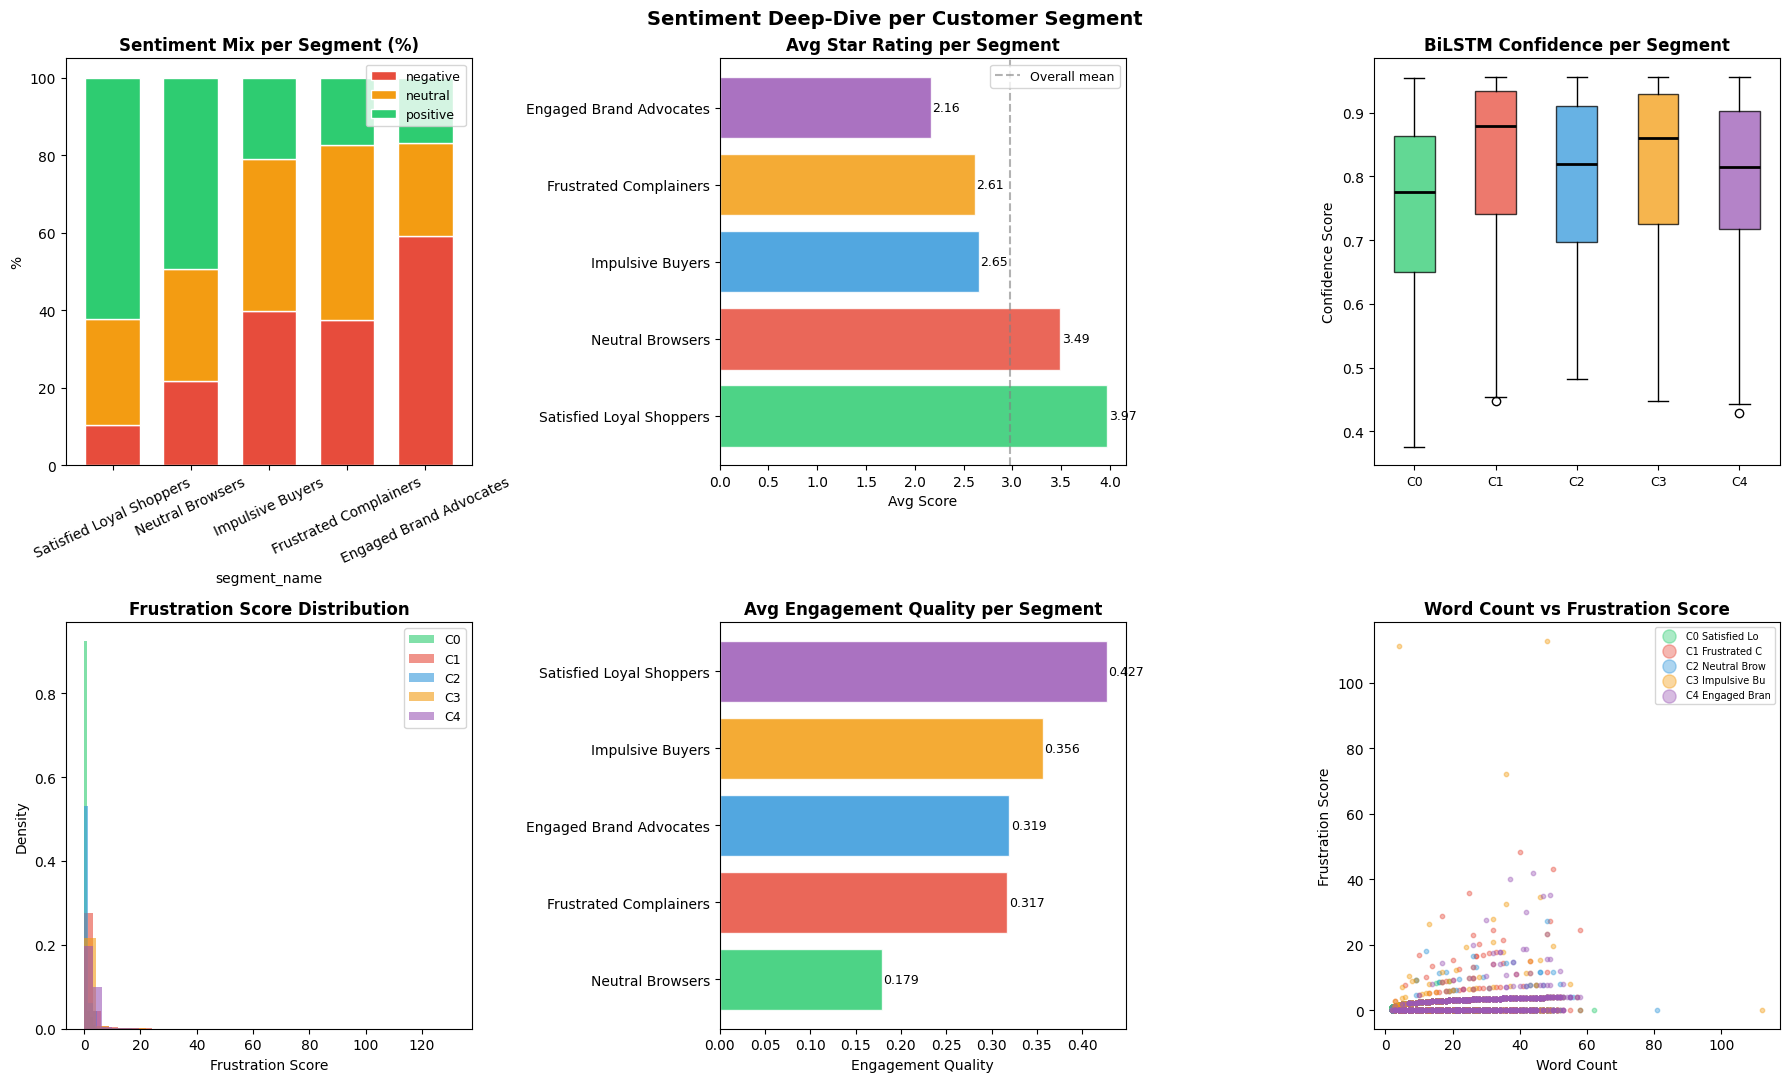


── Kruskal-Wallis Test (score across segments) ──
   H-statistic : 18312.9732
   p-value     : 0.000000
   Significant : ✅ YES


In [5]:
log.info('Analyzing sentiment distribution per segment...')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Sentiment Deep-Dive per Customer Segment',
             fontweight='bold', fontsize=14)

sent_colors = {
    'positive': '#2ecc71',
    'neutral' : '#f39c12',
    'negative': '#e74c3c'
}

# ── 1. Stacked bar — sentiment % per segment
sent_dist = pd.crosstab(
    df['segment_name'],
    df['sentiment'],
    normalize='index'
) * 100

# reorder rows by positive %
sent_dist = sent_dist.loc[
    sent_dist['positive'].sort_values(ascending=False).index
]

sent_dist.plot(
    kind='bar', stacked=True, ax=axes[0, 0],
    color=[sent_colors.get(c, '#95a5a6') for c in sent_dist.columns],
    edgecolor='white', width=0.7
)
axes[0, 0].set_title('Sentiment Mix per Segment (%)', fontweight='bold')
axes[0, 0].set_ylabel('%')
axes[0, 0].tick_params(axis='x', rotation=25)
axes[0, 0].legend(loc='upper right', fontsize=9)

# ── 2. Avg star score per segment
score_means = df.groupby('segment_name')['score'].mean().sort_values(ascending=False)
bar_colors  = [SEGMENT_COLORS[k] for k in
               [k for k, v in SEGMENT_NAMES.items() if v in score_means.index]]
axes[0, 1].barh(score_means.index, score_means.values,
                color=[SEGMENT_COLORS[k]
                       for k, v in SEGMENT_NAMES.items()
                       if v in score_means.index],
                edgecolor='white', alpha=0.85)
axes[0, 1].axvline(score_means.mean(), color='gray',
                   linestyle='--', alpha=0.6, label='Overall mean')
axes[0, 1].set_title('Avg Star Rating per Segment', fontweight='bold')
axes[0, 1].set_xlabel('Avg Score')
axes[0, 1].legend(fontsize=9)
for i, v in enumerate(score_means.values):
    axes[0, 1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

# ── 3. BiLSTM confidence per segment
if 'bilstm_confidence' in df.columns:
    conf_data = [
        df[df['final_cluster'] == k]['bilstm_confidence'].dropna().values
        for k in range(CFG['k'])
    ]
    bp = axes[0, 2].boxplot(
        conf_data,
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2)
    )
    for patch, k in zip(bp['boxes'], range(CFG['k'])):
        patch.set_facecolor(SEGMENT_COLORS[k])
        patch.set_alpha(0.75)
    axes[0, 2].set_xticklabels(
        [f'C{k}' for k in range(CFG['k'])], fontsize=9
    )
    axes[0, 2].set_title('BiLSTM Confidence per Segment', fontweight='bold')
    axes[0, 2].set_ylabel('Confidence Score')

# ── 4. Frustration score distribution
for k in range(CFG['k']):
    subset = df[df['final_cluster'] == k]['frustration_score'].dropna()
    axes[1, 0].hist(subset, bins=30, alpha=0.6,
                    color=SEGMENT_COLORS[k],
                    label=f'C{k}', density=True)
axes[1, 0].set_title('Frustration Score Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Frustration Score')
axes[1, 0].set_ylabel('Density')
axes[1, 0].legend(fontsize=9)

# ── 5. Engagement quality per segment
eng_means = df.groupby('segment_name')['engagement_quality'].mean().sort_values()
axes[1, 1].barh(eng_means.index, eng_means.values,
                color=[SEGMENT_COLORS[k]
                       for k, v in SEGMENT_NAMES.items()
                       if v in eng_means.index],
                edgecolor='white', alpha=0.85)
axes[1, 1].set_title('Avg Engagement Quality per Segment', fontweight='bold')
axes[1, 1].set_xlabel('Engagement Quality')
for i, v in enumerate(eng_means.values):
    axes[1, 1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)

# ── 6. Word count vs frustration scatter (sampled)
sample = df.sample(n=min(5000, len(df)), random_state=SEED)
for k in range(CFG['k']):
    mask = sample['final_cluster'] == k
    axes[1, 2].scatter(
        sample[mask]['word_count'],
        sample[mask]['frustration_score'],
        c=SEGMENT_COLORS[k], alpha=0.4, s=10,
        label=f'C{k} {SEGMENT_NAMES[k][:12]}'
    )
axes[1, 2].set_title('Word Count vs Frustration Score', fontweight='bold')
axes[1, 2].set_xlabel('Word Count')
axes[1, 2].set_ylabel('Frustration Score')
axes[1, 2].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_sentiment_deepdive.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Statistical test: Kruskal-Wallis across segments
kw_stat, kw_p = kruskal(*[
    df[df['final_cluster'] == k]['score'].dropna().values
    for k in range(CFG['k'])
])
print(f'\n── Kruskal-Wallis Test (score across segments) ──')
print(f'   H-statistic : {kw_stat:.4f}')
print(f'   p-value     : {kw_p:.6f}')
print(f'   Significant : {"✅ YES" if kw_p < 0.05 else "❌ NO"}')

# Platform × Segment Cross-Analysis

2026-04-25 16:48:52,645 | INFO | Analyzing platform × segment interactions...


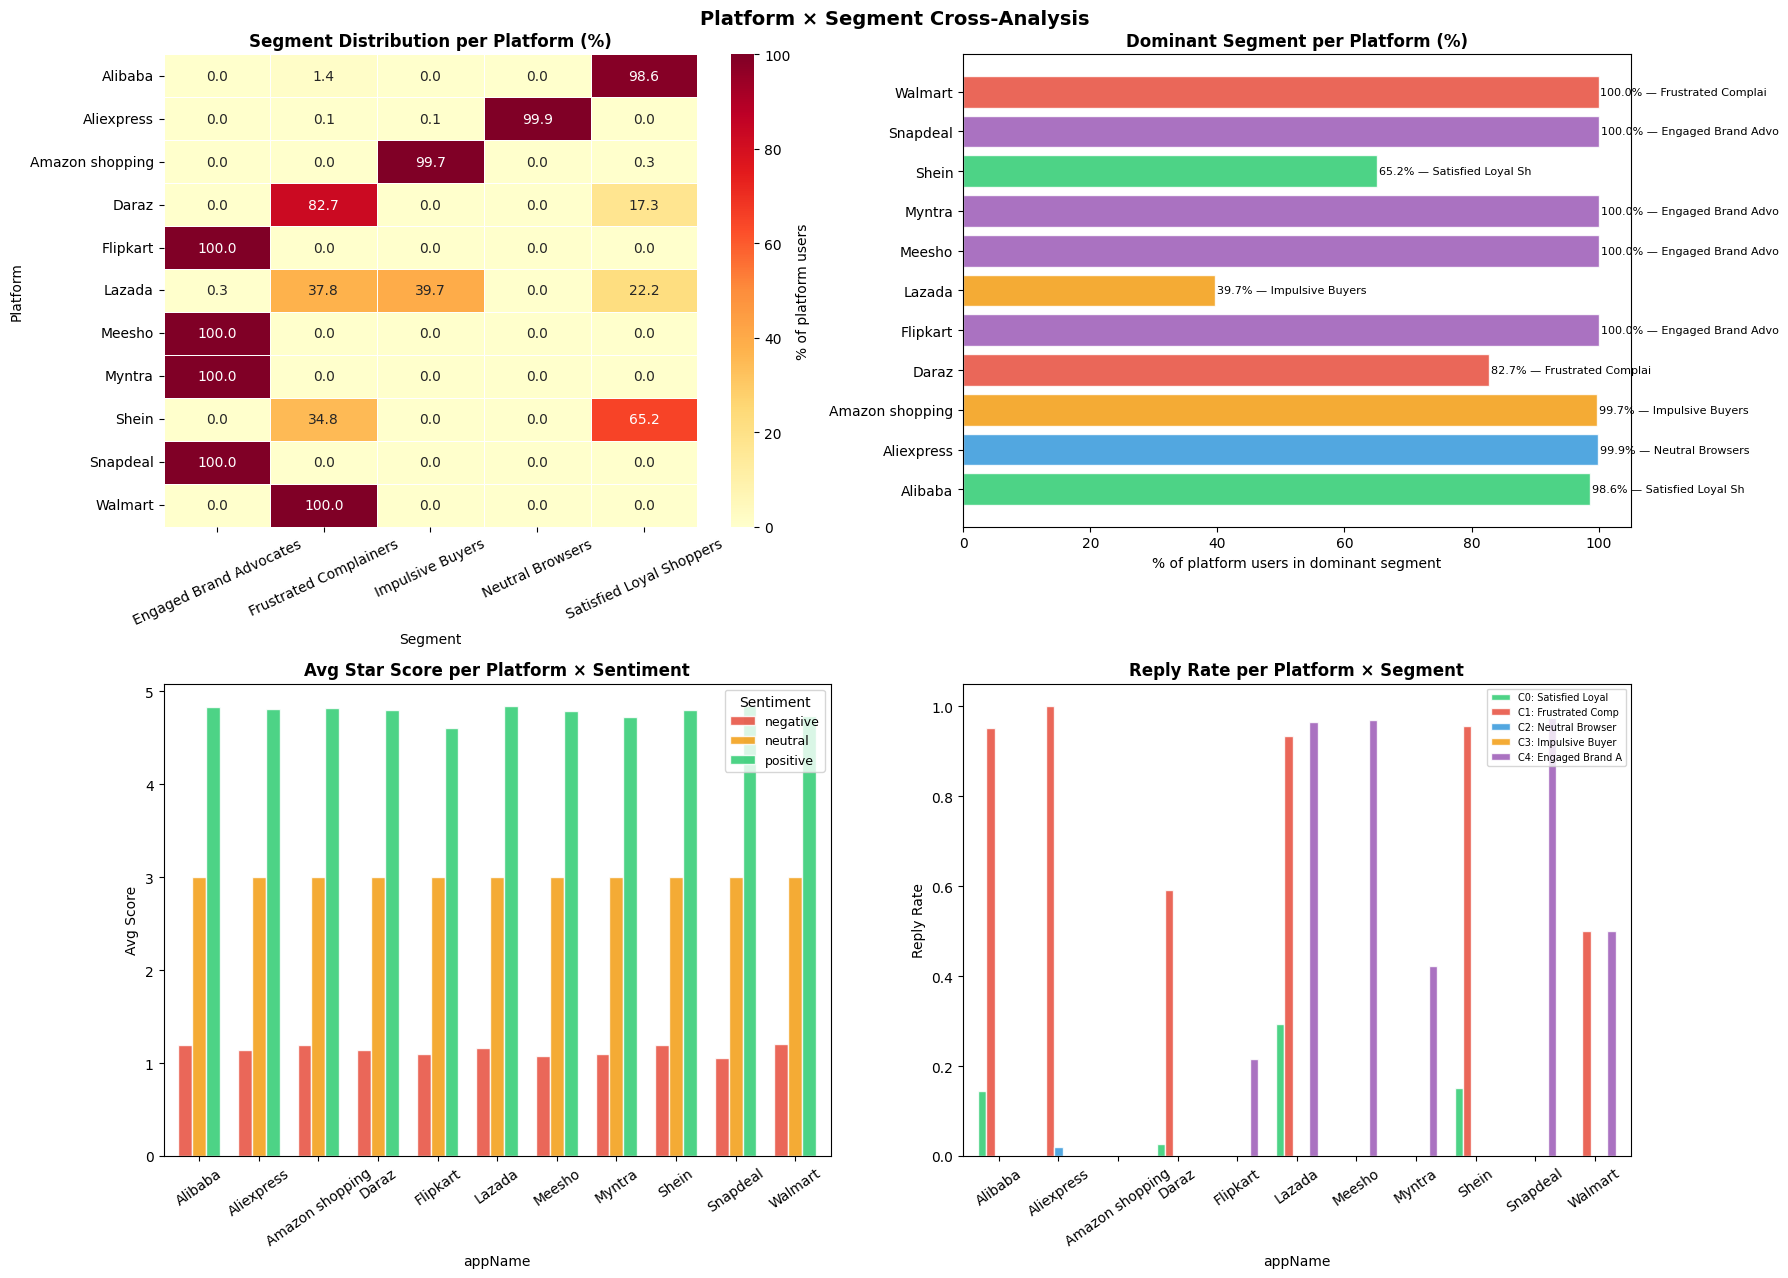


── Chi-Square Test (platform vs segment) ──
   Chi2 statistic : 345743.1841
   p-value        : 0.000000
   Degrees of freedom : 40
   Significant    : ✅ YES


In [6]:
log.info('Analyzing platform × segment interactions...')

# ── Cross-tab: segment distribution per platform
platform_segment = pd.crosstab(
    df['appName'],
    df['segment_name'],
    normalize='index'
) * 100

# ── Short platform names for plotting
short_names = {p: p.replace(' Online Shopping App', '')
                    .replace(' online shopping & selling', '')
                    .replace(' - Online Shopping', '')
               for p in platform_segment.index}
platform_segment.index = platform_segment.index.map(short_names)

fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.suptitle('Platform × Segment Cross-Analysis',
             fontweight='bold', fontsize=14)

# ── 1. Heatmap — segment % per platform
sns.heatmap(
    platform_segment,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': '% of platform users'},
    ax=axes[0, 0]
)
axes[0, 0].set_title('Segment Distribution per Platform (%)',
                      fontweight='bold')
axes[0, 0].set_xlabel('Segment')
axes[0, 0].set_ylabel('Platform')
axes[0, 0].tick_params(axis='x', rotation=25)

# ── 2. Dominant segment per platform (bar)
dominant = platform_segment.idxmax(axis=1)
dom_pct  = platform_segment.max(axis=1)
dom_colors = [
    SEGMENT_COLORS[[k for k, v in SEGMENT_NAMES.items() if v == seg][0]]
    for seg in dominant
]
axes[0, 1].barh(dominant.index, dom_pct.values,
                color=dom_colors, edgecolor='white', alpha=0.85)
axes[0, 1].set_title('Dominant Segment per Platform (%)',
                      fontweight='bold')
axes[0, 1].set_xlabel('% of platform users in dominant segment')
for i, (v, seg) in enumerate(zip(dom_pct.values, dominant)):
    axes[0, 1].text(v + 0.3, i, f'{v:.1f}% — {seg[:18]}',
                    va='center', fontsize=8)

# ── 3. Avg score per platform × sentiment group
plat_sent_score = df.groupby(['appName', 'sentiment'])['score'].mean().unstack()
plat_sent_score.index = plat_sent_score.index.map(short_names)
plat_sent_score.plot(
    kind='bar', ax=axes[1, 0],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white', alpha=0.85, width=0.7
)
axes[1, 0].set_title('Avg Star Score per Platform × Sentiment',
                      fontweight='bold')
axes[1, 0].set_ylabel('Avg Score')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].legend(title='Sentiment', fontsize=9)

# ── 4. Reply rate per platform × segment
plat_reply = df.groupby(['appName', 'final_cluster'])['has_reply'].mean().unstack()
plat_reply.index = plat_reply.index.map(short_names)
plat_reply.columns = [f'C{k}' for k in plat_reply.columns]
plat_reply.plot(
    kind='bar', ax=axes[1, 1],
    color=[SEGMENT_COLORS[k] for k in range(CFG['k'])],
    edgecolor='white', alpha=0.85, width=0.7
)
axes[1, 1].set_title('Reply Rate per Platform × Segment',
                      fontweight='bold')
axes[1, 1].set_ylabel('Reply Rate')
axes[1, 1].tick_params(axis='x', rotation=35)
axes[1, 1].legend(
    [f'C{k}: {SEGMENT_NAMES[k][:15]}' for k in range(CFG['k'])],
    fontsize=7, loc='upper right'
)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_platform_segment_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Chi-square test: platform vs segment
chi2, p_chi, dof, _ = chi2_contingency(
    pd.crosstab(df['appName'], df['final_cluster'])
)
print(f'\n── Chi-Square Test (platform vs segment) ──')
print(f'   Chi2 statistic : {chi2:.4f}')
print(f'   p-value        : {p_chi:.6f}')
print(f'   Degrees of freedom : {dof}')
print(f'   Significant    : {"✅ YES" if p_chi < 0.05 else "❌ NO"}')

# Temporal & Engagement Pattern Analysis

2026-04-25 16:48:54,831 | INFO | Analyzing temporal and engagement patterns...


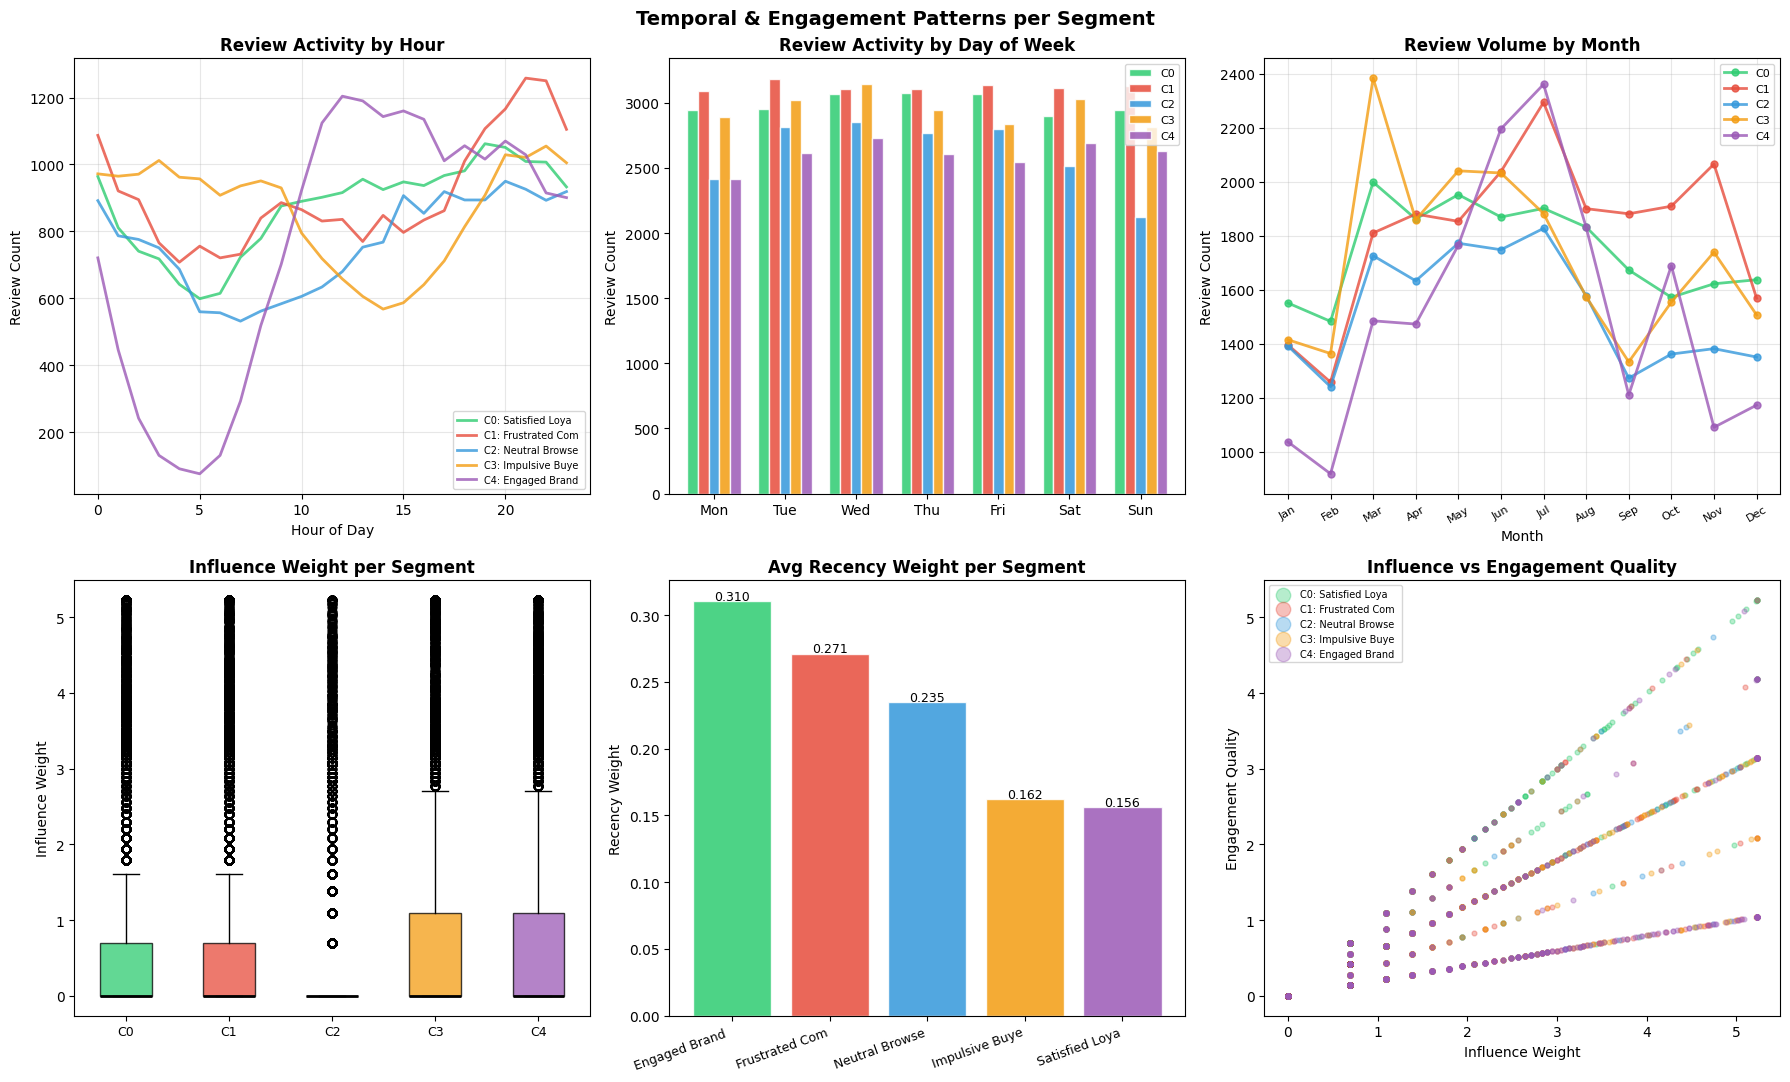


── Temporal Summary per Segment ──
                          avg_hour  pct_weekend  avg_recency  avg_influence  avg_engagement
segment_name                                                                               
Engaged Brand Advocates     14.143        0.292        0.310          0.763           0.319
Frustrated Complainers      12.232        0.285        0.271          0.658           0.317
Impulsive Buyers            11.293        0.283        0.162          0.719           0.356
Neutral Browsers            12.245        0.254        0.235          0.320           0.179
Satisfied Loyal Shoppers    12.284        0.279        0.156          0.569           0.427


In [7]:
log.info('Analyzing temporal and engagement patterns...')

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Temporal & Engagement Patterns per Segment',
             fontweight='bold', fontsize=14)

# ── 1. Review hour distribution per segment
if 'review_hour' in df.columns:
    for k in range(CFG['k']):
        subset = df[df['final_cluster'] == k]['review_hour'].dropna()
        axes[0, 0].plot(
            subset.value_counts().sort_index().index,
            subset.value_counts().sort_index().values,
            color=SEGMENT_COLORS[k], linewidth=2,
            label=f'C{k}: {SEGMENT_NAMES[k][:14]}', alpha=0.8
        )
    axes[0, 0].set_title('Review Activity by Hour', fontweight='bold')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Review Count')
    axes[0, 0].legend(fontsize=7)
    axes[0, 0].grid(True, alpha=0.3)

# ── 2. Review day of week per segment
if 'review_dayofweek' in df.columns:
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    day_data = df.groupby(['review_dayofweek', 'final_cluster']).size().unstack(fill_value=0)
    day_data.index = day_labels[:len(day_data)]
    day_data.columns = [f'C{k}' for k in day_data.columns]
    day_data.plot(
        kind='bar', ax=axes[0, 1],
        color=[SEGMENT_COLORS[k] for k in range(CFG['k'])],
        edgecolor='white', alpha=0.85, width=0.75
    )
    axes[0, 1].set_title('Review Activity by Day of Week', fontweight='bold')
    axes[0, 1].set_ylabel('Review Count')
    axes[0, 1].tick_params(axis='x', rotation=0)
    axes[0, 1].legend(fontsize=8)

# ── 3. Monthly trend per segment
if 'review_month' in df.columns:
    month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec']
    for k in range(CFG['k']):
        subset = df[df['final_cluster'] == k]['review_month'].value_counts().sort_index()
        axes[0, 2].plot(
            subset.index, subset.values,
            'o-', color=SEGMENT_COLORS[k], linewidth=2,
            markersize=5, label=f'C{k}', alpha=0.8
        )
    axes[0, 2].set_title('Review Volume by Month', fontweight='bold')
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Review Count')
    axes[0, 2].set_xticks(range(1, 13))
    axes[0, 2].set_xticklabels(month_labels, rotation=30, fontsize=8)
    axes[0, 2].legend(fontsize=8)
    axes[0, 2].grid(True, alpha=0.3)

# ── 4. Influence weight per segment
inf_data = [
    df[df['final_cluster'] == k]['influence_weight'].dropna().values
    for k in range(CFG['k'])
]
bp = axes[1, 0].boxplot(
    inf_data, patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
for patch, k in zip(bp['boxes'], range(CFG['k'])):
    patch.set_facecolor(SEGMENT_COLORS[k])
    patch.set_alpha(0.75)
axes[1, 0].set_xticklabels([f'C{k}' for k in range(CFG['k'])], fontsize=9)
axes[1, 0].set_title('Influence Weight per Segment', fontweight='bold')
axes[1, 0].set_ylabel('Influence Weight')

# ── 5. Recency weight per segment
rec_means = df.groupby('segment_name')['recency_weight'].mean().sort_values(ascending=False)
axes[1, 1].bar(
    range(len(rec_means)), rec_means.values,
    color=[SEGMENT_COLORS[k] for k, v in SEGMENT_NAMES.items()
           if v in rec_means.index],
    edgecolor='white', alpha=0.85
)
axes[1, 1].set_xticks(range(len(rec_means)))
axes[1, 1].set_xticklabels(
    [s[:14] for s in rec_means.index],
    rotation=20, ha='right', fontsize=9
)
axes[1, 1].set_title('Avg Recency Weight per Segment', fontweight='bold')
axes[1, 1].set_ylabel('Recency Weight')
for i, v in enumerate(rec_means.values):
    axes[1, 1].text(i, v + 0.001, f'{v:.3f}', ha='center', fontsize=9)

# ── 6. Engagement quality vs influence scatter
sample = df.sample(n=min(8000, len(df)), random_state=SEED)
for k in range(CFG['k']):
    mask = sample['final_cluster'] == k
    axes[1, 2].scatter(
        sample[mask]['influence_weight'],
        sample[mask]['engagement_quality'],
        c=SEGMENT_COLORS[k], alpha=0.35, s=12,
        label=f'C{k}: {SEGMENT_NAMES[k][:14]}'
    )
axes[1, 2].set_title('Influence vs Engagement Quality', fontweight='bold')
axes[1, 2].set_xlabel('Influence Weight')
axes[1, 2].set_ylabel('Engagement Quality')
axes[1, 2].legend(fontsize=7, markerscale=3)

plt.tight_layout()
plt.savefig(FIG_DIR / '06_temporal_engagement.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('\n── Temporal Summary per Segment ──')
temporal_summary = df.groupby('segment_name').agg(
    avg_hour        = ('review_hour', 'mean'),
    pct_weekend     = ('is_weekend', 'mean'),
    avg_recency     = ('recency_weight', 'mean'),
    avg_influence   = ('influence_weight', 'mean'),
    avg_engagement  = ('engagement_quality', 'mean'),
).round(3)
print(temporal_summary.to_string())

# Segment Summary Report Export

In [8]:
log.info('Building segment summary report...')

# ── Comprehensive profile per segment
PROFILE_COLS = [
    'score', 'word_count', 'char_per_word', 'unique_word_ratio',
    'exclamation_count', 'frustration_score', 'engagement_quality',
    'recency_weight', 'influence_weight', 'has_reply',
    'log_response_time', 'complaint_depth', 'positive_brevity',
    'review_hour', 'is_weekend',
] + BILSTM_FEATURES
PROFILE_COLS = [c for c in PROFILE_COLS if c in df.columns]

segment_summary = df.groupby('final_cluster').agg(
    segment_name    = ('segment_name',  'first'),
    n_users         = ('score',         'count'),
    avg_score       = ('score',         'mean'),
    pct_positive    = ('sentiment',     lambda x: (x == 'positive').mean() * 100),
    pct_negative    = ('sentiment',     lambda x: (x == 'negative').mean() * 100),
    pct_neutral     = ('sentiment',     lambda x: (x == 'neutral').mean()  * 100),
    avg_word_count  = ('word_count',    'mean'),
    avg_frustration = ('frustration_score', 'mean'),
    avg_engagement  = ('engagement_quality','mean'),
    avg_influence   = ('influence_weight',  'mean'),
    avg_recency     = ('recency_weight',    'mean'),
    reply_rate      = ('has_reply',         'mean'),
    pct_weekend     = ('is_weekend',        'mean'),
    top_platform    = ('appName',    lambda x: x.value_counts().index[0]),
).round(3)

print('=' * 75)
print('  SEGMENT SUMMARY REPORT')
print('=' * 75)
print(segment_summary.T.to_string())

# ── Business insight per segment
INSIGHTS = {
    0: '🟢 High satisfaction, short reviews, low frustration. '
       'Target with loyalty rewards and upsell campaigns.',
    1: '🔴 Long reviews, high frustration, frequent replies needed. '
       'Priority for customer service intervention.',
    2: '🔵 Mid-range satisfaction, low engagement. '
       'Activate with personalized nudges and discovery content.',
    3: '🟡 Impulsive, high negative rate, zero reply rate. '
       'Target with return policy reassurance and trust signals.',
    4: '🟣 Most verbose, highest frustration, highest influence. '
       'Critical segment — address issues publicly, turn into advocates.',
}

print('\n── Business Insights per Segment ──')
for k, insight in INSIGHTS.items():
    print(f'\n   Cluster {k} | {SEGMENT_NAMES[k]}')
    print(f'   {insight}')

# ── Export segment summary
segment_summary.to_csv(OUT_DIR / 'segment_summary.csv')
print(f'\n✅ Segment summary saved → {OUT_DIR / "segment_summary.csv"}')

# ── Export enriched df
EXPORT_COLS = [
    'appName', 'sentiment', 'score',
    'final_cluster', 'segment_name',
    'frustration_score', 'engagement_quality',
    'influence_weight', 'recency_weight',
    'word_count', 'has_reply',
] + BILSTM_FEATURES
EXPORT_COLS = [c for c in EXPORT_COLS if c in df.columns]

df[EXPORT_COLS].to_csv(OUT_DIR / 'enriched_profiles.csv', index=False)
print(f'✅ Enriched profiles saved → {OUT_DIR / "enriched_profiles.csv"}')

# ── Export insights as JSON
insights_export = {
    str(k): {
        'segment_name'   : SEGMENT_NAMES[k],
        'n_users'        : int(segment_summary.loc[k, 'n_users']),
        'avg_score'      : float(segment_summary.loc[k, 'avg_score']),
        'pct_positive'   : float(segment_summary.loc[k, 'pct_positive']),
        'pct_negative'   : float(segment_summary.loc[k, 'pct_negative']),
        'top_platform'   : segment_summary.loc[k, 'top_platform'],
        'business_insight': INSIGHTS[k],
    }
    for k in range(CFG['k'])
}
with open(OUT_DIR / 'segment_insights.json', 'w') as f:
    json.dump(insights_export, f, indent=2)
print(f'✅ Segment insights saved → {OUT_DIR / "segment_insights.json"}')

2026-04-25 16:48:57,663 | INFO | Building segment summary report...


  SEGMENT SUMMARY REPORT
final_cluster                           0                       1                 2                 3                        4
segment_name     Satisfied Loyal Shoppers  Frustrated Complainers  Neutral Browsers  Impulsive Buyers  Engaged Brand Advocates
n_users                             20952                   21851             18285             20682                    18229
avg_score                           3.968                   2.614             3.491             2.654                    2.163
pct_positive                        62.39                  17.404            49.264            21.067                   16.967
pct_negative                       10.338                  37.422            21.635            39.875                   59.175
pct_neutral                        27.272                  45.174              29.1            39.058                   23.858
avg_word_count                      8.848                  19.591            14.044   

#  MLflow Logging & Final Summary

In [9]:
log.info('Logging to MLflow...')

mlflow.set_tracking_uri(str(LOG_DIR))
mlflow.set_experiment(CFG['experiment_name'])

with mlflow.start_run(run_name=CFG['run_name']) as run:
    RUN_ID = run.info.run_id

    # ── Parameters
    mlflow.log_params({
        'n_segments'      : CFG['k'],
        'n_behavior_feats': len(BEHAVIOR_FEATURES),
        'n_bilstm_feats'  : len(BILSTM_FEATURES),
        'n_platform_feats': len(PLATFORM_FEATURES),
        'sample_size'     : len(df),
    })

    # ── Metrics per segment
    for k in range(CFG['k']):
        prefix = f'seg{k}'
        mlflow.log_metrics({
            f'{prefix}_n_users'        : int(segment_summary.loc[k, 'n_users']),
            f'{prefix}_avg_score'      : float(segment_summary.loc[k, 'avg_score']),
            f'{prefix}_pct_positive'   : float(segment_summary.loc[k, 'pct_positive']),
            f'{prefix}_pct_negative'   : float(segment_summary.loc[k, 'pct_negative']),
            f'{prefix}_avg_frustration': float(segment_summary.loc[k, 'avg_frustration']),
            f'{prefix}_avg_engagement' : float(segment_summary.loc[k, 'avg_engagement']),
        })

    # ── Global metrics
    mlflow.log_metrics({
        'chi2_platform_segment' : round(chi2, 4),
        'chi2_p_value'          : round(p_chi, 6),
        'kw_stat_score'         : round(kw_stat, 4),
        'kw_p_value'            : round(kw_p, 6),
    })

    # ── Figures
    for fig_file in FIG_DIR.glob('06_*.png'):
        mlflow.log_artifact(str(fig_file), artifact_path='figures')

    # ── Artifacts
    mlflow.log_artifact(str(OUT_DIR / 'segment_summary.csv'),   artifact_path='profiles')
    mlflow.log_artifact(str(OUT_DIR / 'segment_insights.json'), artifact_path='profiles')
    mlflow.log_dict(insights_export, 'segment_insights.json')

print(f'✅ MLflow Run ID: {RUN_ID}')

# ── Final summary
print('\n' + '=' * 55)
print('  nb-06 Cluster Profiling COMPLETE')
print('=' * 55)
for k in range(CFG['k']):
    print(f'  Cluster {k} | {SEGMENT_NAMES[k]:<30}'
          f' | n={int(segment_summary.loc[k,"n_users"]):,}'
          f' | score={segment_summary.loc[k,"avg_score"]:.2f}'
          f' | pos={segment_summary.loc[k,"pct_positive"]:.1f}%')
print('=' * 55)
print(f'  Chi2 p-value   : {p_chi:.6f}  ✅')
print(f'  KW   p-value   : {kw_p:.6f}  ✅')
print(f'  MLflow Run ID  : {RUN_ID}')
print('=' * 55)


2026-04-25 16:48:58,570 | INFO | Logging to MLflow...
2026/04/25 16:48:58 INFO mlflow.tracking.fluent: Experiment with name '04_Cluster_Profiling_Behavioral_Analysis' does not exist. Creating a new experiment.


✅ MLflow Run ID: c9f852d67a2148feb7c81938931dcb3e

  nb-06 Cluster Profiling COMPLETE
  Cluster 0 | Satisfied Loyal Shoppers       | n=20,952 | score=3.97 | pos=62.4%
  Cluster 1 | Frustrated Complainers         | n=21,851 | score=2.61 | pos=17.4%
  Cluster 2 | Neutral Browsers               | n=18,285 | score=3.49 | pos=49.3%
  Cluster 3 | Impulsive Buyers               | n=20,682 | score=2.65 | pos=21.1%
  Cluster 4 | Engaged Brand Advocates        | n=18,229 | score=2.16 | pos=17.0%
  Chi2 p-value   : 0.000000  ✅
  KW   p-value   : 0.000000  ✅
  MLflow Run ID  : c9f852d67a2148feb7c81938931dcb3e
